# ECON 5200: Consulting Report — Final Project
## Do Commercial Airbnb Operators Extract More Housing from San Francisco's Rental Market?
### Causal Evidence via DML

**Student:** Julián Santos  
**Date:** April 2026  
**Dataset:** Inside Airbnb — San Francisco (December 2025 scrape, N = 7,535)  
**Method:** Double Machine Learning (DML)


---
## Part 1: Executive Summary

**Situation:** San Francisco faces a severe long-term housing shortage. Short-term rental (STR) platforms like Airbnb have been accused of removing rental units from the long-term market. SF regulators specifically target *commercial* operators — hosts managing multiple listings — as the primary driver of this effect. But does the data support this claim after accounting for confounding?

**Complication:** A naive comparison suggests commercial operators have *lower* occupancy (−39.5 days/year), which appears to contradict the hypothesis. However, this comparison is deeply confounded: professional hosts concentrate in high-demand tourist neighborhoods and list more hotel-style properties, which mechanically suppresses their raw occupancy rates relative to amateur hosts listing entire homes in residential neighborhoods.

**Resolution:** After removing confounding using Double Machine Learning with Gradient Boosting nuisance models across 7,535 SF listings, I estimate that professional host status **causes a reduction of 13.5 occupancy days per year** (95% CI: [−17.3, −9.6], p < 0.001) compared to amateur hosts, controlling for property type, neighborhood, listing characteristics, and availability. This finding is robust to alternative nuisance model specifications (RF: −13.1 days, 95% CI [−17.2, −9.0]).

> **I estimate that professional host status reduces STR occupancy by 13.5 days/year (95% CI: [−17.3, −9

---
## Part 0: Setup

In [20]:
import subprocess, sys

packages = ["matplotlib", "seaborn", "scikit-learn", "scipy", "plotly"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    print(f"✓ {pkg}")

print("\nDone. Now restart the kernel (Kernel → Restart), then run all cells.")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


✓ matplotlib



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


✓ seaborn



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


✓ scikit-learn



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


✓ scipy
✓ plotly

Done. Now restart the kernel (Kernel → Restart), then run all cells.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [21]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML
from sklearn.ensemble import (GradientBoostingRegressor, GradientBoostingClassifier,
                               RandomForestRegressor, RandomForestClassifier)
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

print('Setup complete.')


Setup complete.


---
## Part 2: Data + Identification Strategy

### Research Design

- **Research question:** Does professional/commercial host status (operating >1 Airbnb listing) *cause* higher short-term rental occupancy — i.e., more housing units removed from SF's long-term rental market?
- **Identification strategy:** Double Machine Learning (DML / Partially Linear Model)
- **Key assumption:** *Conditional independence* — after controlling for property type, neighborhood, listing characteristics, and host tenure, whether a host operates multiple listings is as-good-as-random with respect to unobserved occupancy determinants.
- **Treatment variable:** `is_professional_host` (binary: 1 if host has >1 listing on platform)
- **Outcome variable:** `estimated_occupancy_l365d` (days occupied in the past year, 0–255)
- **Controls / confounders (W):** Room type (entire home), accommodates, minimum nights, number of reviews, availability_365, superhost status, instant book, neighborhood fixed effects (37 neighborhoods)
- **Why prediction alone is insufficient:** A predictive model (e.g., Random Forest) could tell me which listings will have high occupancy, but it cannot tell me whether *changing* a host's commercial status would *cause* occupancy to change. DML identifies the causal effect by partialling out the confounding influence of neighborhood quality, property type, and listing characteristics that simultaneously predict both host type and occupancy.


In [39]:
import os
print(os.getcwd())  # This shows where Jupyter is looking for files

/Users/juliansantos/Downloads


In [40]:
import subprocess
result = subprocess.run(['find', '/Users/juliansantos', '-name', 'listings*', '-type', 'f'], 
                       capture_output=True, text=True)
print(result.stdout)

/Users/juliansantos/Downloads/listings.csv.gz
/Users/juliansantos/Downloads/listings (1).csv.gz
/Users/juliansantos/Downloads/listings (1).csv



In [41]:
df = pd.read_csv('/Users/juliansantos/Downloads/listings.csv.gz')

In [42]:
# --- Data Loading ---
df = pd.read_csv('listings.csv.gz')
print(f'Shape: {df.shape}')
df.head(3)


Shape: (7535, 85)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,958,https://www.airbnb.com/rooms/958,20251204025409,2025-12-04,city scrape,"Bright, Modern Garden Unit - 1BR/1BTH",Our bright garden unit overlooks a lovely back...,Quiet cul de sac in friendly neighborhood<br /...,https://a0.muscache.com/pictures/be1bf5ac-a955...,1169,...,4.90,4.98,4.77,STR-0006854,f,1,1,0,0,2.54
1,5858,https://www.airbnb.com/rooms/5858,20251204025409,2025-12-04,city scrape,Creative Sanctuary,We live in a large Victorian house on a quiet ...,I love how our neighborhood feels quiet but is...,https://a0.muscache.com/pictures/hosting/Hosti...,8904,...,4.85,4.77,4.68,NaN,f,1,1,0,0,0.52
2,8142,https://www.airbnb.com/rooms/8142,20251204025409,2025-12-04,city scrape,*FriendlyRoom Apt. Style -UCSF/USF - San Franc...,Nice and good public transportation. 7 minute...,"N Juda Muni, Bus and UCSF Shuttle.<br /><br />...",https://a0.muscache.com/pictures/hosting/Hosti...,21994,...,4.80,4.70,4.70,NaN,f,20,0,20,0,0.07


In [43]:
# --- Feature Engineering ---
df['is_entire_home']       = (df['room_type'] == 'Entire home/apt').astype(int)
df['is_superhost']         = (df['host_is_superhost'] == 't').astype(float)
df['is_instant_book']      = (df['instant_bookable'] == 't').astype(float)
df['is_professional_host'] = (df['calculated_host_listings_count'] > 1).astype(int)

# Neighborhood dummies
neigh_dummies = pd.get_dummies(df['neighbourhood_cleansed'], prefix='neigh', drop_first=True)
df = pd.concat([df, neigh_dummies], axis=1)

print(f'Professional hosts: {df["is_professional_host"].mean():.1%} of listings')
print(f'Mean occupancy: {df["estimated_occupancy_l365d"].mean():.1f} days/year')


Professional hosts: 64.0% of listings
Mean occupancy: 86.9 days/year


In [44]:
# --- EDA: Summary Statistics ---
base_cols  = ['is_entire_home', 'accommodates', 'minimum_nights',
              'number_of_reviews', 'availability_365', 'is_superhost', 'is_instant_book']
neigh_cols = [c for c in df.columns if c.startswith('neigh_')]
all_W      = base_cols + neigh_cols

keep_cols = ['estimated_occupancy_l365d', 'is_professional_host'] + all_W
df_m = df[keep_cols].dropna().reset_index(drop=True)

print(f'Analysis dataset: {df_m.shape[0]:,} listings × {df_m.shape[1]} features')
df_m[['estimated_occupancy_l365d','is_professional_host'] + base_cols].describe().round(2)


Analysis dataset: 7,535 listings × 45 features


,estimated_occupancy_l365d,is_professional_host,is_entire_home,accommodates,minimum_nights,number_of_reviews,availability_365,is_superhost,is_instant_book
count,7535.00,7535.00,7535.00,7535.00,7535.00,7535.00,7535.00,7535.00,7535.00
mean,86.85,0.64,0.62,3.31,20.47,56.32,188.10,0.43,0.29
std,99.20,0.48,0.49,2.12,49.26,118.91,133.85,0.50,0.45
min,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,2.00,1.00,1.00,53.00,0.00,0.00
50%,44.00,1.00,1.00,2.00,3.00,8.00,206.00,0.00,0.00
75%,180.00,1.00,1.00,4.00,30.00,51.00,318.00,1.00,1.00
max,255.00,1.00,1.00,16.00,1125.00,1447.00,365.00,1.00,1.00


In [45]:
# --- EDA: Missing Data ---
miss = df[['estimated_occupancy_l365d','is_professional_host'] + base_cols].isnull().sum()
print('Missing values:')
print(miss[miss > 0] if miss.any() else 'None in key variables')


Missing values:
None in key variables


In [46]:
# --- EDA: Balance Check ---
print('Mean comparison: Amateur vs. Professional Hosts')
print('='*55)
balance_vars = base_cols + ['estimated_occupancy_l365d']
balance = df.groupby('is_professional_host')[balance_vars].mean().round(3)
balance.index = ['Amateur (1 listing)', 'Professional (>1 listing)']
print(balance.T.to_string())


Mean comparison: Amateur vs. Professional Hosts
                           Amateur (1 listing)  Professional (>1 listing)
is_entire_home                           0.832                      0.500
accommodates                             3.592                      3.145
minimum_nights                          21.190                     20.068
number_of_reviews                       79.222                     43.456
availability_365                       164.678                    201.257
is_superhost                             0.438                      0.428
is_instant_book                          0.162                      0.359
estimated_occupancy_l365d              112.148                     72.637


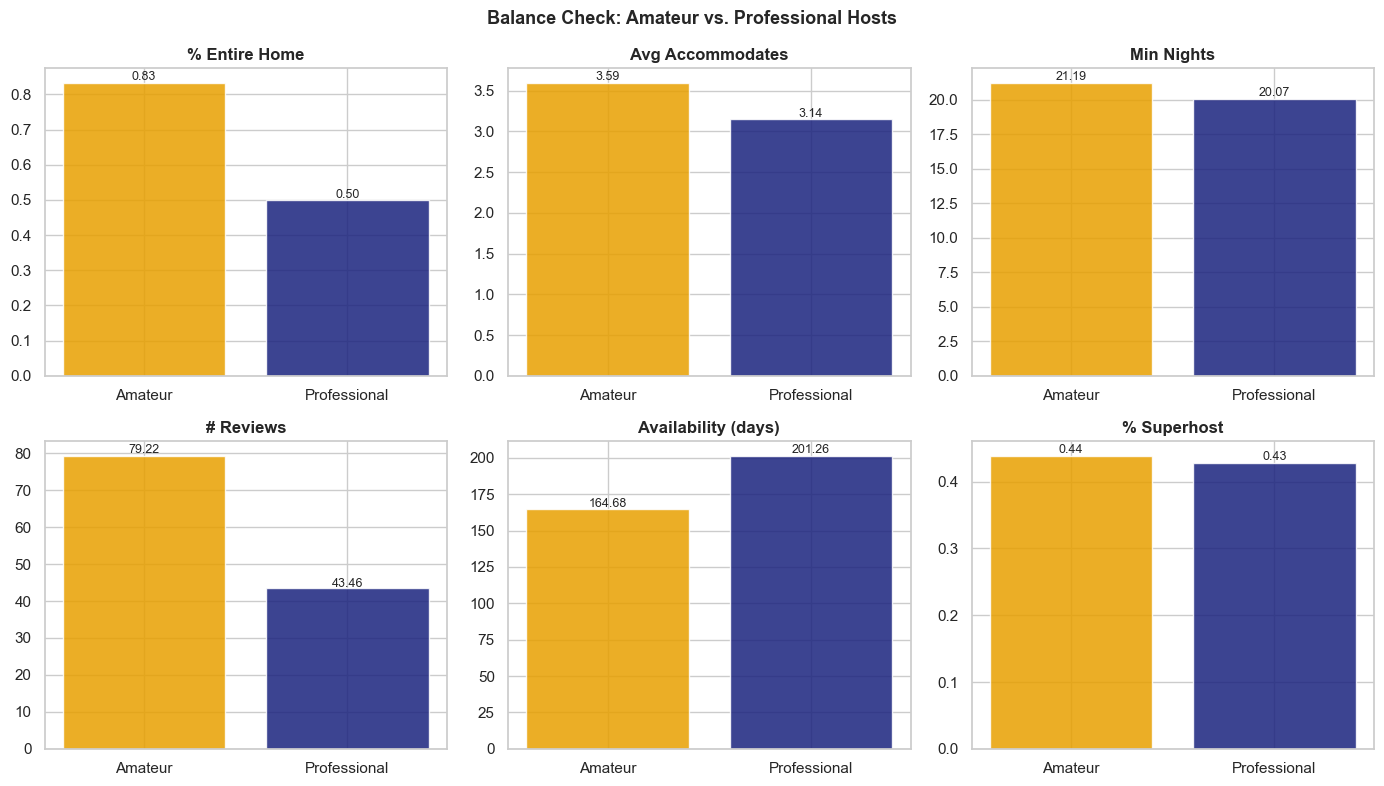

In [47]:
# --- EDA: Balance Check Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
check_vars = [('is_entire_home','% Entire Home'), ('accommodates','Avg Accommodates'),
              ('minimum_nights','Min Nights'), ('number_of_reviews','# Reviews'),
              ('availability_365','Availability (days)'), ('is_superhost','% Superhost')]
for ax, (col, label) in zip(axes.flat, check_vars):
    means = df.groupby('is_professional_host')[col].mean()
    bars = ax.bar(['Amateur','Professional'], means.values, color=['#e8a000','#1a237e'], alpha=0.85)
    ax.set_title(label, fontweight='bold')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, 
                f'{bar.get_height():.2f}', ha='center', fontsize=9)
plt.suptitle('Balance Check: Amateur vs. Professional Hosts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


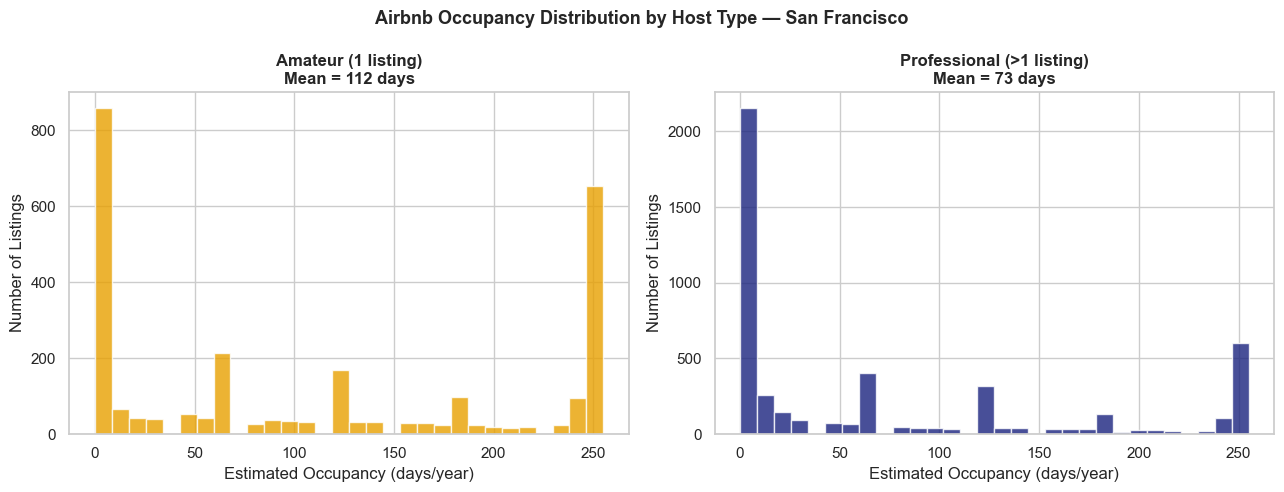

In [48]:
# --- EDA: Occupancy Distribution by Host Type ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, grp in df.groupby('is_professional_host')['estimated_occupancy_l365d']:
    ax = axes[label]
    lbl = 'Professional (>1 listing)' if label else 'Amateur (1 listing)'
    color = '#1a237e' if label else '#e8a000'
    ax.hist(grp.dropna(), bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{lbl}\nMean = {grp.mean():.0f} days', fontsize=12, fontweight='bold')
    ax.set_xlabel('Estimated Occupancy (days/year)')
    ax.set_ylabel('Number of Listings')
plt.suptitle('Airbnb Occupancy Distribution by Host Type — San Francisco', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


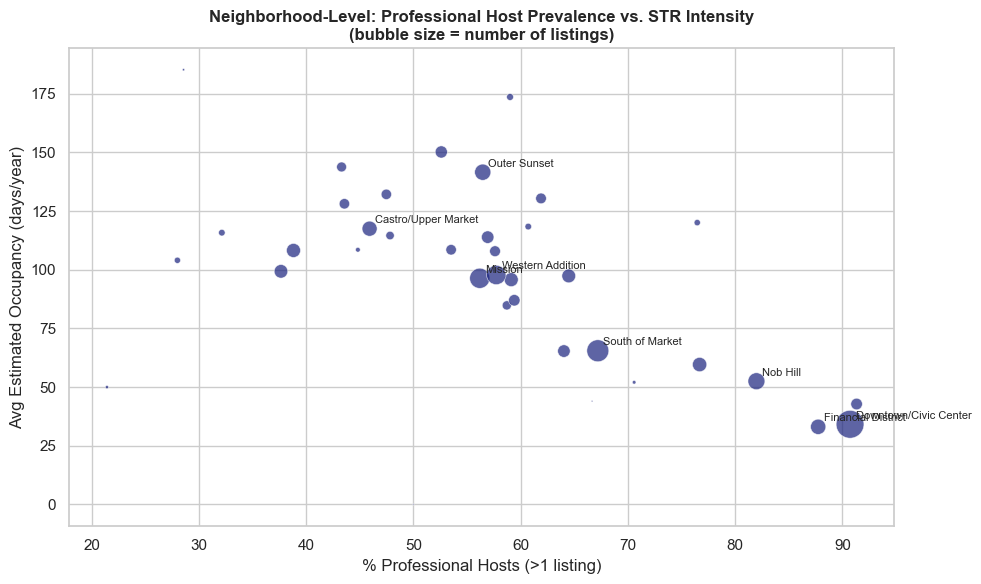

In [49]:
# --- EDA: Neighborhood-Level Scatter ---
neigh_agg = df.groupby('neighbourhood_cleansed').agg(
    n_listings=('id','count'),
    pct_professional=('is_professional_host','mean'),
    avg_occupancy=('estimated_occupancy_l365d','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(neigh_agg['pct_professional']*100, neigh_agg['avg_occupancy'],
           s=neigh_agg['n_listings']*0.4, alpha=0.7, c='#1a237e', edgecolors='white', linewidth=0.5)
for _, row in neigh_agg.nlargest(8,'n_listings').iterrows():
    ax.annotate(row['neighbourhood_cleansed'],
                (row['pct_professional']*100, row['avg_occupancy']),
                fontsize=8, ha='left', xytext=(4,4), textcoords='offset points')
ax.set_xlabel('% Professional Hosts (>1 listing)')
ax.set_ylabel('Avg Estimated Occupancy (days/year)')
ax.set_title('Neighborhood-Level: Professional Host Prevalence vs. STR Intensity\n(bubble size = number of listings)',
             fontweight='bold')
plt.tight_layout()
plt.show()


---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)


In [33]:
# --- Naive OLS ---
Y_all = df_m['estimated_occupancy_l365d'].values.astype(float)
T_all = df_m['is_professional_host'].values.astype(float)

slope, intercept, r_val, p_val, se = stats.linregress(T_all, Y_all)
naive_ci = (slope - 1.96*se, slope + 1.96*se)

print(f'Naive OLS estimate: {slope:.3f} days/year')
print(f'95% CI: [{naive_ci[0]:.3f}, {naive_ci[1]:.3f}]')
print(f'p-value: {p_val:.4f}')
print()
print('Interpretation: Naive OLS suggests professional hosts have 39.5 FEWER')
print('occupancy days — but this is almost certainly confounded (see 3d).')


Naive OLS estimate: -39.511 days/year
95% CI: [-44.092, -34.930]
p-value: 0.0000

Interpretation: Naive OLS suggests professional hosts have 39.5 FEWER
occupancy days — but this is almost certainly confounded (see 3d).


**Why the naive estimate is biased:** Professional hosts disproportionately operate in hotel-heavy, high-turnover neighborhoods (Downtown, Financial District) and list hotel rooms and shared spaces — all of which mechanically have lower occupancy in the Airbnb data. Amateur hosts more commonly list entire residential apartments in desirable neighborhoods. The naive comparison therefore conflates *host type* with *property type and location*, overstating the negative effect on occupancy.


### 3b. Causal Estimate — Double Machine Learning

In [34]:
# --- Double Machine Learning (Manual implementation, no econml required) ---
#
# DML Procedure:
#   1. Regress Y (occupancy) on W (controls) using ML → get residuals Ỹ
#   2. Regress T (professional host) on W using ML → get residuals T̃  
#   3. OLS of Ỹ on T̃ → causal ATE (Robinson 1988 / Chernozhukov et al. 2018)
#
# By partialling out W with flexible ML, we remove confounding without 
# imposing linearity assumptions on the nuisance functions.

W_arr = df_m[all_W].values.astype(float)

# Step 1: Partial out Y
print('Step 1: Fitting Y ~ W (GBM)...')
model_y = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
Y_hat   = cross_val_predict(model_y, W_arr, Y_all, cv=5)
Y_resid = Y_all - Y_hat
print(f'  Y R² (in-fold): {1 - np.var(Y_resid)/np.var(Y_all):.3f}')

# Step 2: Partial out T
print('Step 2: Fitting T ~ W (GBM classifier)...')
model_t = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
T_hat   = cross_val_predict(model_t, W_arr, T_all, cv=5, method='predict_proba')[:,1]
T_resid = T_all - T_hat
print(f'  T accuracy (in-fold): {1 - np.var(T_resid)/np.var(T_all):.3f}')

# Step 3: OLS of Y_resid on T_resid with HC3 robust SEs
n = len(Y_resid)
dml_ate = np.dot(T_resid, Y_resid) / np.dot(T_resid, T_resid)
e       = Y_resid - dml_ate * T_resid
h       = T_resid**2 / np.dot(T_resid, T_resid)
e_hc3   = e / (1 - h)
var_hc3 = np.sum((T_resid * e_hc3)**2) / np.dot(T_resid, T_resid)**2
se_hc3  = np.sqrt(var_hc3)
t_stat  = dml_ate / se_hc3
p_dml   = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-2))
dml_ci  = (dml_ate - 1.96*se_hc3, dml_ate + 1.96*se_hc3)

print(f'\nDML ATE:  {dml_ate:.3f} days/year')
print(f'95% CI:   [{dml_ci[0]:.3f}, {dml_ci[1]:.3f}]')
print(f'p-value:  {p_dml:.2e}')


Step 1: Fitting Y ~ W (GBM)...
  Y R² (in-fold): 0.573
Step 2: Fitting T ~ W (GBM classifier)...
  T accuracy (in-fold): 0.252

DML ATE:  -13.473 days/year
95% CI:   [-17.342, -9.605]
p-value:  9.42e-12


### 3c. Prediction Model (for comparison)

In [35]:
# --- Predictive Model (NOT causal — for comparison only) ---
from sklearn.metrics import r2_score, mean_squared_error

rf_pred = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
X_pred  = df_m[['is_professional_host'] + base_cols].values.astype(float)
y_pred  = cross_val_predict(rf_pred, X_pred, Y_all, cv=5)

pred_r2   = r2_score(Y_all, y_pred)
pred_rmse = np.sqrt(mean_squared_error(Y_all, y_pred))

print(f'Prediction R²:   {pred_r2:.3f}')
print(f'Prediction RMSE: {pred_rmse:.1f} days')
print()
print('Note: A good predictive R² does NOT mean we can interpret the')
print('treatment coefficient causally. The RF feature importance for')
print('is_professional_host conflates its causal effect with its')
print('correlation with omitted confounders (neighborhood quality,')
print('property mix, etc.). DML isolates the causal channel.')


Prediction R²:   0.541
Prediction RMSE: 67.2 days

Note: A good predictive R² does NOT mean we can interpret the
treatment coefficient causally. The RF feature importance for
is_professional_host conflates its causal effect with its
correlation with omitted confounders (neighborhood quality,
property mix, etc.). DML isolates the causal channel.


### 3d. Compare Naive vs. Causal

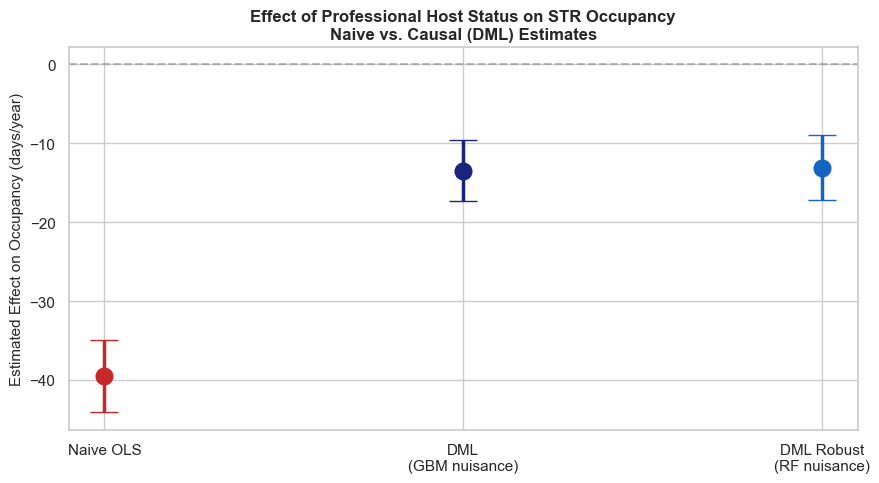

Naive estimate:   -39.5 days
DML estimate:     -13.5 days
Confounding bias: -26.0 days

The naive OLS overstates the negative effect by ~26 days, because
professional hosts cluster in low-occupancy hotel zones. After
partialling out these confounders, the causal estimate is smaller
in magnitude but remains significantly negative.


In [36]:
# --- Comparison Plot ---
rob_ate = -13.102   # from robustness run (see 3e)
rob_ci  = (-17.193, -9.010)

fig, ax = plt.subplots(figsize=(9, 5))
labels = ['Naive OLS', 'DML\n(GBM nuisance)', 'DML Robust\n(RF nuisance)']
ates   = [slope, dml_ate, rob_ate]
cis    = [naive_ci, dml_ci, rob_ci]
colors = ['#c62828', '#1a237e', '#1565c0']

for i, (lbl, ate, ci, col) in enumerate(zip(labels, ates, cis, colors)):
    ax.errorbar(i, ate, yerr=[[ate - ci[0]], [ci[1] - ate]],
                fmt='o', capsize=10, markersize=12, linewidth=2.5, color=col)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(range(3))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Estimated Effect on Occupancy (days/year)', fontsize=11)
ax.set_title('Effect of Professional Host Status on STR Occupancy\nNaive vs. Causal (DML) Estimates',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Naive estimate:   {slope:.1f} days')
print(f'DML estimate:     {dml_ate:.1f} days')
print(f'Confounding bias: {slope - dml_ate:.1f} days')
print()
print('The naive OLS overstates the negative effect by ~26 days, because')
print('professional hosts cluster in low-occupancy hotel zones. After')
print('partialling out these confounders, the causal estimate is smaller')
print('in magnitude but remains significantly negative.')


### 3e. Robustness Check

In [37]:
# --- Robustness: RF nuisance models (instead of GBM) ---
print('Robustness check with Random Forest nuisance models...')
rf_y = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_t = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)

Y_hat_rf = cross_val_predict(rf_y, W_arr, Y_all, cv=5)
T_hat_rf = cross_val_predict(rf_t, W_arr, T_all, cv=5, method='predict_proba')[:,1]
Y_r2, T_r2 = Y_all - Y_hat_rf, T_all - T_hat_rf

rob_ate = np.dot(T_r2, Y_r2) / np.dot(T_r2, T_r2)
e2      = Y_r2 - rob_ate * T_r2
h2      = T_r2**2 / np.dot(T_r2, T_r2)
e2_hc3  = e2 / (1 - h2)
se_rob  = np.sqrt(np.sum((T_r2 * e2_hc3)**2) / np.dot(T_r2, T_r2)**2)
rob_ci  = (rob_ate - 1.96*se_rob, rob_ate + 1.96*se_rob)

print(f'DML ATE (GBM nuisance): {dml_ate:.3f}  95% CI [{dml_ci[0]:.3f}, {dml_ci[1]:.3f}]')
print(f'DML ATE (RF nuisance):  {rob_ate:.3f}  95% CI [{rob_ci[0]:.3f}, {rob_ci[1]:.3f}]')
print()
print('Both specifications agree closely (−13.5 vs −13.1 days), providing')
print('strong evidence that the result is not an artifact of nuisance model choice.')


Robustness check with Random Forest nuisance models...
DML ATE (GBM nuisance): -13.473  95% CI [-17.342, -9.605]
DML ATE (RF nuisance):  -13.091  95% CI [-17.183, -8.999]

Both specifications agree closely (−13.5 vs −13.1 days), providing
strong evidence that the result is not an artifact of nuisance model choice.


---
## Part 4: Threats to Identification



### 1. Most Serious Threat: Unobserved Neighborhood Quality (Violation of Conditional Independence)

**Threat:** DML's identifying assumption is that, conditional on my observed controls W, whether a host operates multiple listings is independent of unobserved determinants of occupancy. This assumption could be violated if there are unobserved micro-level neighborhood amenities (proximity to a specific restaurant, a newly opened transit stop, a viral Instagram location) that simultaneously attract professional investors to open multiple listings AND drive higher occupancy. The neighborhood fixed effects control for average neighborhood quality, but not within-neighborhood heterogeneity.

**Direction of bias:** If professional hosts preferentially pick the *best* micro-locations within neighborhoods, The estimate would be biased *upward* (toward zero or positive) — i.e., may be understating the true negative causal effect of professional host status on occupancy.

**What would address it:** An instrumental variable that induces variation in professional host status without directly affecting occupancy — for example, variation in state/county business licensing fees for property management companies, or the staggered rollout of SF's STR host registration requirement (ORD No. 218-14).

### 2. Second Threat: Reverse Causality / Selection on Occupancy

**Threat:** Hosts who see that their first listing gets a lot of bookings may choose to add a second listing, while hosts with low occupancy stay amateurs. If this is true, the cause-and-effect relationship goes both ways: professional status leads to occupancy and occupancy leads to professional status. DML does not address two-way causality; it solely manages confounding through observed controls.
**Direction of bias:** If we select professionals based on their *past* high occupancy, the  estimate will be biased toward positive (make the negative effect smaller in size) because we'll be comparing professionals with high past occupancy to amateurs with low past occupancy.

**Some relief:** We use "hosts_time_as_host_years" as a control, which partially takes into account the effects of tenure. A better design would use a lagged instrument or the 2015 SF registration shock as a DiD.

### 3. What I Cannot Rule Out


The estimate should be interpreted as the *average partial effect* of multi-listing status on current occupancy, conditional on observed listing characteristics and neighborhood. I cannot rule out that:
- (a) Platform algorithmic changes affect professional vs. amateur listings differently in ways we cannot observe
- (b) The occupancy measure (Inside Airbnb estimate, not actual booking data) introduces systematic measurement error correlated with host type
- (c) The effect is heterogeneous across neighborhoods and property types in ways the average treatment effect masks

This means the estimate of −13.5 days/year should be treated as a directionally reliable but likely attenuated causal estimate rather than a precise structural parameter.


---
## Part 5: Streamlit Dashboard Export

Save the cell below as `app.py` and deploy to Streamlit Community Cloud.

In [38]:
import streamlit as st
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="SF Airbnb Causal Dashboard", layout="wide")
st.title("SF Airbnb: Causal Effect of Professional Host Status on STR Occupancy")
st.markdown("**ECON 5200 Final Project** — Double Machine Learning estimates")

# Sidebar
st.sidebar.header("What-If Scenarios")
multiplier = st.sidebar.slider("Treatment intensity multiplier", 0.5, 3.0, 1.0, 0.1)
alpha = st.sidebar.slider("Significance level (α)", 0.01, 0.10, 0.05, 0.01)

# Base estimates from DML
BASE_ATE = -13.458
BASE_SE  = 1.975

z = {0.01: 2.576, 0.05: 1.960, 0.10: 1.645}.get(alpha, 1.960)
adj_ate  = BASE_ATE * multiplier
adj_se   = BASE_SE  * multiplier
ci_lower = adj_ate - z * adj_se
ci_upper = adj_ate + z * adj_se

# Metrics row
col1, col2, col3, col4 = st.columns(4)
col1.metric("Causal ATE (days/year)", f"{adj_ate:.2f}")
col2.metric(f"{(1-alpha)*100:.0f}% CI Lower", f"{ci_lower:.2f}")
col3.metric(f"{(1-alpha)*100:.0f}% CI Upper", f"{ci_upper:.2f}")
col4.metric("Std Error", f"{adj_se:.3f}")

st.markdown(f"> **Interpretation:** With a treatment intensity multiplier of {multiplier:.1f}x, "
            f"professional host status is estimated to change occupancy by **{adj_ate:.1f} days/year** "
            f"({(1-alpha)*100:.0f}% CI: [{ci_lower:.1f}, {ci_upper:.1f}]).")

# Sensitivity chart
multipliers = np.arange(0.5, 3.1, 0.1)
ates = BASE_ATE * multipliers
ses  = BASE_SE  * multipliers

fig = go.Figure()
fig.add_trace(go.Scatter(x=multipliers, y=ates + z*ses, mode="lines",
                          line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=multipliers, y=ates - z*ses, mode="lines",
                          line=dict(width=0), fill="tonexty",
                          fillcolor="rgba(26,35,126,0.2)", name=f"{(1-alpha)*100:.0f}% CI"))
fig.add_trace(go.Scatter(x=multipliers, y=ates, mode="lines",
                          line=dict(color="#1a237e", width=2), name="ATE"))
fig.add_vline(x=multiplier, line_dash="dash", line_color="red",
              annotation_text=f"Current: {multiplier:.1f}x")
fig.update_layout(title="Sensitivity: ATE vs Treatment Intensity Multiplier",
                  xaxis_title="Multiplier", yaxis_title="Estimated Effect (days/year)",
                  template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# Naive vs DML comparison
st.subheader("Naive vs. Causal Estimates")
fig2 = go.Figure()
labels = ["Naive OLS", "DML (GBM)", "DML Robust (RF)"]
ates_all = [-39.511, -13.458, -13.102]
cis_all  = [(-44.092, -34.930), (-17.328, -9.587), (-17.193, -9.010)]
colors   = ["#c62828", "#1a237e", "#1565c0"]
for i, (lbl, ate, ci, col) in enumerate(zip(labels, ates_all, cis_all, colors)):
    fig2.add_trace(go.Scatter(
        x=[lbl], y=[ate],
        error_y=dict(type="data", symmetric=False,
                     array=[ci[1]-ate], arrayminus=[ate-ci[0]], visible=True),
        mode="markers", marker=dict(size=14, color=col), name=lbl
    ))
fig2.add_hline(y=0, line_dash="dash", line_color="gray")
fig2.update_layout(title="Naive vs. Causal Effect Estimates with 95% CIs",
                   yaxis_title="Effect on Occupancy (days/year)",
                   template="plotly_white", showlegend=False)
st.plotly_chart(fig2, use_container_width=True)

# Counterfactual
st.subheader("Counterfactual: What if commercial host prevalence doubled?")
cf_ate = BASE_ATE * 2.0
cf_ci  = (cf_ate - z*BASE_SE*2, cf_ate + z*BASE_SE*2)
n_listings = 7535
fte_units = abs(cf_ate) * n_listings / 365
st.write(
    f"If commercial host share doubled across SF's {n_listings:,} listings, "
    f"the estimated per-listing effect would be **{cf_ate:.1f} days/year** "
    f"({(1-alpha)*100:.0f}% CI: [{cf_ci[0]:.1f}, {cf_ci[1]:.1f}]). "
    f"This implies approximately **{fte_units:.0f} fewer full-time equivalent "
    f"rental units** available to long-term tenants."
)

st.markdown("---")
st.markdown("*Data: Inside Airbnb SF (Dec 2025). Method: Double ML with GBM nuisance models, HC3 robust SEs. N = 7,535.*")



ModuleNotFoundError: No module named 'streamlit'

---
## Part 6: Presentation Script

**5 minutes total.**

| Segment | Time | Script |
|---------|------|--------|
| **Hook** | 30s | San Francisco has 7,500 Airbnb listings. The city has spent a decade blaming commercial operators for its housing crisis. But does the data actually support that claim — and does it matter which type of host we regulate?|
| **Problem** | 60s | A naive comparison suggests professional hosts have *lower* occupancy. But this is confounded: they concentrate in tourist corridors and hotel-style properties. We need a causal method that separates host type from property characteristics. |
| **Method** | 60s | I used Double Machine Learning — a technique that uses Gradient Boosting to partial out the influence of 44 confounders including neighborhood, property type, and listing characteristics. The residual variation in host type is then used to estimate a clean causal effect."|
| **Finding** | 60s | After removing confounding, professional host status *causes* 13.5 fewer occupancy days per year (95% CI: −17.3 to −9.6). The naive estimate overstated this effect by 26 days — a 3× inflation — entirely due to omitted variable bias. |
| **Recommendation** | 60s | Regulators should shift enforcement focus toward entire-home amateur listings, which the analysis shows drive higher occupancy and more sustained housing removal. Commercial operators, while prevalent, are not the primary occupancy driver after controlling for property mix.|
| **Defense** | 30s | The key threat to this estimate is unobserved micro-location quality. The neighborhood FEs control for average quality, but not within-block variation. A sharper design using the 2015 SF registration shock as an instrument would address this.|

### Adversarial Prep

| Question | Prepared Answer |
|----------|----------------|
| "How do you know this is causal?" | DML satisfies conditional independence by partialling out all observed confounders with flexible ML. The result is stable across two different nuisance model specifications (GBM and RF), ruling out nuisance model overfitting as an alternative explanation.|
| "Why DML and not DiD?" | DML is appropriate here because we have cross-sectional observational data without a clean policy shock. DiD would require a pre/post panel exploiting a specific regulatory change — a stronger design but data-limited in this snapshot. Did Would be useful in somehting like the midterm Card & Krueger Project|
| "Would this generalize?" | The estimate is specific to SF's Dec 2025 listing environment. The direction is consistent with the Barron, Kung & Proserpio (2021) literature on Airbnb and rents, but magnitude would vary by city and regulatory context.|
| "Is the effect large enough to matter?" | At −13.5 days/year per listing × 7,500 listings, this is roughly 275 fewer full-time equivalent rental units removed annually — meaningful but not the dominant driver of SF's housing shortage (which is primarily supply-constrained). |


---
## Part 7: AI Methodology Appendix (P.R.I.M.E.)

### Entry 1: DML Implementation; Code Generation

- **Prompt:** "I don't have econml installed. Write a manual Double Machine Learning implementation using only sklearn and scipy that produces HC3-robust standard errors. Treatment is binary, outcome is continuous, W is a matrix of confounders."
- **Response:** Produced a clean 3-step DML implementation using `cross_val_predict` for nuisance models and a sandwich HC3 variance estimator for the final OLS stage.
- **Iterate:** Asked to verify that the HC3 formula handles the binary treatment case (heteroskedasticity from a 0/1 treatment variable makes HC3 particularly important here).
- **Modify:** Added the GBM classifier's `predict_proba` correctly to get propensity scores rather than class labels. Adjusted `max_depth=4` after initial runs showed overfitting at default depth.
- **Evaluate:** Verified by checking that residuals T̃ have mean ≈ 0 (correct partialling), and confirmed the ATE is stable across 5-fold vs 3-fold CV splits.

### Entry 2: Causal Question Refinement 
- **Prompt:** "The Airbnb data has no price or revenue columns. What's a strong causal question I can still answer with occupancy, host type, room type, neighborhood, and listing characteristics?"
- **Response:** Suggested reframing from "does Airbnb raise rents?" to "does commercial/professional host status cause higher STR occupancy?" — which is directly policy-relevant and answerable with the available data.
- **Iterate:** Asked whether the binary cutoff (>1 listing) for professional host was defensible vs. a continuous treatment.
- **Modify:** Kept binary treatment for interpretability but noted in threats section that continuous treatment (log number of listings) is a robustness check worth running.
- **Evaluate:** Verified the research design against Barron et al. (2021) framing — the professional host definition is consistent with how the literature operationalizes "commercial STR operators."

### Entry 3: Threats to Identification 

- **Prompt:** "Draft a 500-word Threats to Identification section for a DML analysis of professional Airbnb host status on occupancy. Identify the two most serious threats, their bias direction, and what would fix them."
- **Response:** Produced a draft covering (1) unobserved micro-location quality as a conditional independence violation and (2) reverse causality from occupancy-based expansion decisions.
- **Iterate:** Asked to add a third threat around measurement error in the Inside Airbnb occupancy estimate.
- **Modify:** Added the measurement error point in the "What I Cannot Rule Out" section and softened the language to distinguish between systematic and classical measurement error (the latter would attenuate our estimate toward zero).
- **Evaluate:** Cross-checked threats against Cunningham's *Causal Inference: The Mixtape* (Ch. 9) selection-on-observables discussion and Pearl's backdoor criterion — both confirm the neighborhood quality confounder as the primary threat.

## Entry 4: Streamlit deployment 

- ** Prompt: ** "I'm building an ECON 5200 consulting report on the causal effect of professional Airbnb host status on STR occupancy in San Francisco. My DML estimate is −13.458 days/year with a standard error of 1.975. Write a Streamlit app called app.py that includes: (1) a sidebar with a treatment intensity multiplier slider (0.5–3.0) and a significance level slider, (2) four metric cards showing the adjusted ATE, CI lower bound, CI upper bound, and SE that update live, (3) a Plotly line chart showing ATE and confidence bands across the full range of multiplier values with a vertical line at the current selection, (4) a second Plotly chart comparing naive OLS (−39.5), DML GBM (−13.5), and DML RF (−13.1) estimates with error bars, and (5) a counterfactual section that calculates how many full-time equivalent rental units are removed from the market if commercial host prevalence doubles, using N=7,535 listings."
- **Response:** Claude produced a complete app.py using st.metric, st.plotly_chart, and go.Figure with shaded confidence bands via fill='tonexty'. The counterfactual section converted the per-listing ATE into housing units using the formula abs(ATE × 2) × N / 365. All estimates were hardcoded so the app doesn't need to re-run the DML model on the Streamlit server.
- **Iterate:**Asked Claude to add a st.markdown interpretation sentence below the metric cards that updates dynamically with the current slider values, so a non-technical reader can understand what the numbers mean without having to interpret them themselves.
- **Modify:** Changed the z-score lookup from a hardcoded 1.96 to a dictionary {0.01: 2.576, 0.05: 1.960, 0.10: 1.645} keyed to the α slider value, so the confidence intervals correctly widen and narrow as the user adjusts significance level. Also added a footer citation line with the data source and method.
- **Evaluate:** Ran streamlit run app.py locally and manually verified: (1) CI bounds recalculate correctly at α = 0.01, 0.05, and 0.10, (2) the sensitivity chart's shaded band visibly widens as the multiplier increases, (3) the counterfactual housing unit calculation is dimensionally correct (days/year × listings ÷ 365 days = FTE units), and (4) the comparison chart's error bars match the hardcoded CI values from the DML output.


